In [ ]:
import importlib, subprocess, sys

pkgs = {
    "torch": "torch",
    "scipy": "scipy>=1.10,<2.0",  # Ensure compatible scipy version
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "tqdm": "tqdm",
    "pandas": "pandas",
}

# Here I am defining required libraries and their versions for installation

In [ ]:
import sys
import json, time, math, random, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from tqdm.notebook import tqdm
from sklearn.metrics.pairwise import cosine_similarity

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Here I am importing all necessary libraries for PyTorch, data manipulation, visualization, and computing


Device: cpu


## Step 2 – Load & Prepare Corpus

In [ ]:
DATA_DIR = "data"

with open(os.path.join(DATA_DIR, "iitj_tokens.json"), "r", encoding="utf-8") as f:
    token_data = json.load(f)

# token_data is a list of dicts each with "tokens" key (list of strings)
sentences = [d["tokens"] for d in token_data if d.get("tokens")]
all_tokens = [tok for sent in sentences for tok in sent]

print(f"Total sentences  : {len(sentences):,}")
print(f"Total tokens     : {len(all_tokens):,}")
print(f"Sample sentence  : {sentences[0][:15]}")

# Here I am loading the tokenized corpus from JSON file and preparing sentences and tokens for processing


Total sentences  : 11
Total tokens     : 15,121
Sample sentence  : ['about', 'iit', 'jodhpur', 'indian', 'institute', 'of', 'technology', 'jodhpur', 'was', 'established', 'in', 'to', 'foster', 'technology', 'education']


In [ ]:
MIN_COUNT = 2   # discard words appearing < MIN_COUNT times

counter = Counter(all_tokens)
vocab_words = [w for w, c in counter.items() if c >= MIN_COUNT]
vocab_size   = len(vocab_words)

word2idx = {w: i for i, w in enumerate(vocab_words)}
idx2word = {i: w for w, i in word2idx.items()}

# Frequency array (used for negative sampling noise distribution)
freq_arr = np.array([counter[w] for w in vocab_words], dtype=np.float32)
freq_arr = freq_arr ** 0.75
noise_dist = freq_arr / freq_arr.sum()  # normalised P(w)^0.75

# Filter sentences to vocabulary words only
filtered_sentences = [[w for w in s if w in word2idx] for s in sentences]
filtered_sentences = [s for s in filtered_sentences if len(s) > 1]

print(f"Vocabulary size  : {vocab_size:,}")
print(f"Filtered sents   : {len(filtered_sentences):,}")

# Here I am building vocabulary with MIN_COUNT threshold, creating word2idx mappings, and generating noise distribution for negative sampling


Vocabulary size  : 1,146
Filtered sents   : 11


In [ ]:
class CBOWDataset(Dataset):
    
    def __init__(self, sentences, word2idx, window):
        self.pairs = []
        for sent in sentences:
            idxs = [word2idx[w] for w in sent if w in word2idx]
            for i, target in enumerate(idxs):
                ctx = (idxs[max(0, i-window):i] +
                       idxs[i+1:min(len(idxs), i+window+1)])
                if ctx:
                    self.pairs.append((ctx, target))

    def __len__(self):  return len(self.pairs)

    def __getitem__(self, i):
        ctx, tgt = self.pairs[i]
        return torch.tensor(ctx, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)


def cbow_collate(batch):
   
    ctxs, tgts = zip(*batch)
    max_len = max(len(c) for c in ctxs)
    padded  = torch.zeros(len(ctxs), max_len, dtype=torch.long)
    for i, c in enumerate(ctxs):
        padded[i, :len(c)] = c
    return padded, torch.stack(tgts)


class CBOWModel(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.linear     = nn.Linear(emb_dim, vocab_size)
        nn.init.xavier_uniform_(self.embeddings.weight)
        nn.init.xavier_uniform_(self.linear.weight)

    def forward(self, ctx_idxs):
        # ctx_idxs: (B, ctx_len) → embed → mean → logits
        emb  = self.embeddings(ctx_idxs).mean(dim=1)   # (B, emb_dim)
        return self.linear(emb)                          # (B, vocab_size)

print("CBOW classes defined.")

# Here I am defining CBOW dataset and model classes including the collate function for batch processing


CBOW classes defined.


In [ ]:
class SkipGramNSDataset(Dataset):
    
    def __init__(self, sentences, word2idx, window, neg_samples, noise_dist):
        self.pairs       = []
        self.neg_samples = neg_samples
        self.noise_dist  = noise_dist
        self.vocab_size  = len(word2idx)
        for sent in sentences:
            idxs = [word2idx[w] for w in sent if w in word2idx]
            for i, center in enumerate(idxs):
                ctx = (idxs[max(0, i-window):i] +
                       idxs[i+1:min(len(idxs), i+window+1)])
                for pos in ctx:
                    self.pairs.append((center, pos))

    def __len__(self): return len(self.pairs)

    def __getitem__(self, i):
        center, pos = self.pairs[i]
        negs = np.random.choice(self.vocab_size, size=self.neg_samples,
                                replace=True, p=self.noise_dist).tolist()
        return (torch.tensor(center, dtype=torch.long),
                torch.tensor(pos,    dtype=torch.long),
                torch.tensor(negs,   dtype=torch.long))


class SkipGramNSModel(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.center_emb  = nn.Embedding(vocab_size, emb_dim)
        self.context_emb = nn.Embedding(vocab_size, emb_dim)
        nn.init.xavier_uniform_(self.center_emb.weight)
        nn.init.zeros_(self.context_emb.weight)

    def forward(self, center, pos, negs):
        # center : (B,)   pos : (B,)   negs : (B, K)
        v_c   = self.center_emb(center)            # (B, D)
        u_o   = self.context_emb(pos)              # (B, D)
        u_neg = self.context_emb(negs)             # (B, K, D)

        pos_score = torch.sum(v_c * u_o, dim=1)   # (B,)
        pos_loss  = -torch.log(torch.sigmoid(pos_score) + 1e-10)

        neg_score = torch.bmm(u_neg, v_c.unsqueeze(2)).squeeze(2)  # (B, K)
        neg_loss  = -torch.log(torch.sigmoid(-neg_score) + 1e-10).sum(dim=1)

        return (pos_loss + neg_loss).mean()

    def get_embeddings(self):
       
        return self.center_emb.weight.detach().cpu().numpy()


print("Skip-gram NS classes defined.")

# Here I am defining Skip-gram NS dataset and model classes with negative sampling support


Skip-gram NS classes defined.


In [ ]:
def train_cbow(sentences, word2idx, vocab_size, emb_dim, window,
               epochs=5, lr=0.001, batch_size=256):
    
    ds     = CBOWDataset(sentences, word2idx, window)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True,
                        collate_fn=cbow_collate)
    model  = CBOWModel(vocab_size, emb_dim).to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = []
    t0 = time.time()
    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0
        for ctx, tgt in loader:
            ctx, tgt = ctx.to(DEVICE), tgt.to(DEVICE)
            opt.zero_grad()
            loss = criterion(model(ctx), tgt)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(tgt)
        avg = total_loss / len(ds)
        history.append(avg)
    elapsed = time.time() - t0
    return model, history, elapsed


def train_skipgram_ns(sentences, word2idx, vocab_size, noise_dist,
                      emb_dim, window, neg_samples,
                      epochs=5, lr=0.001, batch_size=256):
    ds     = SkipGramNSDataset(sentences, word2idx, window, neg_samples, noise_dist)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    model  = SkipGramNSModel(vocab_size, emb_dim).to(DEVICE)
    opt    = optim.Adam(model.parameters(), lr=lr)

    history = []
    t0 = time.time()
    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0
        n = 0
        for center, pos, negs in loader:
            center = center.to(DEVICE)
            pos    = pos.to(DEVICE)
            negs   = negs.to(DEVICE)
            opt.zero_grad()
            loss = model(center, pos, negs)
            loss.backward()
            opt.step()
            total_loss += loss.item() * len(center)
            n += len(center)
        history.append(total_loss / n)
    elapsed = time.time() - t0
    return model, history, elapsed


print("Training helpers defined.")

# Here I am defining training functions for both CBOW and Skip-gram NS models with loss tracking


Training helpers defined.


In [ ]:
EMB_DIMS    = [50, 100, 200, 300]
WINDOWS     = [2, 5]
NEG_SAMPLES = [5, 10, 15]
EPOCHS      = 5

# ── CUSTOM CBOW ────────────────────────────────────────────────────────────
cbow_results = []
cbow_models  = {}


print("Training Custom CBOW models …")

for emb in EMB_DIMS:
    for win in WINDOWS:
        key = f"CBOW_d{emb}_w{win}"
        print(f"  [{key}]", end=" ", flush=True)
        m, hist, secs = train_cbow(
            filtered_sentences, word2idx, vocab_size,
            emb_dim=emb, window=win, epochs=EPOCHS
        )
        cbow_models[key] = m
        cbow_results.append({
            "Model": "Custom CBOW", "Emb": emb, "Window": win,
            "NegSamples": "-", "FinalLoss": round(hist[-1], 4),
            "TrainTime(s)": round(secs, 1), "Key": key,
            "LossHistory": hist
        })
        print(f"loss={hist[-1]:.4f}  time={secs:.1f}s")

print("\nCustom CBOW training complete.")

# Here I am training all CBOW models with different embedding dimensions and window sizes


Training Custom CBOW models …
  [CBOW_d50_w2] loss=6.0290  time=4.3s
  [CBOW_d50_w5] loss=5.9714  time=4.1s
  [CBOW_d100_w2] loss=5.9469  time=4.9s
  [CBOW_d100_w5] loss=5.9517  time=5.8s
  [CBOW_d200_w2] loss=5.8497  time=14.7s
  [CBOW_d200_w5] loss=5.9190  time=7.6s
  [CBOW_d300_w2] loss=5.7126  time=8.6s
  [CBOW_d300_w5] loss=5.8847  time=8.2s

Custom CBOW training complete.


In [ ]:
# ── CUSTOM SKIP-GRAM NS ────────────────────────────────────────────────────
sg_results = []
sg_models  = {}


print("Training Custom Skip-gram NS models …")

for emb in EMB_DIMS:
    for win in WINDOWS:
        for neg in NEG_SAMPLES:
            key = f"SG_d{emb}_w{win}_n{neg}"
            print(f"  [{key}]", end=" ", flush=True)
            m, hist, secs = train_skipgram_ns(
                filtered_sentences, word2idx, vocab_size, noise_dist,
                emb_dim=emb, window=win, neg_samples=neg, epochs=EPOCHS
            )
            sg_models[key] = m
            sg_results.append({
                "Model": "Custom SG-NS", "Emb": emb, "Window": win,
                "NegSamples": neg, "FinalLoss": round(hist[-1], 4),
                "TrainTime(s)": round(secs, 1), "Key": key,
                "LossHistory": hist
            })
            print(f"loss={hist[-1]:.4f}  time={secs:.1f}s")

print("\nCustom Skip-gram NS training complete.")

# Here I am training all Skip-gram NS models with different hyperparameter combinations


Training Custom Skip-gram NS models …
  [SG_d50_w2_n5] loss=2.5713  time=27.1s
  [SG_d50_w2_n10] loss=3.2724  time=26.4s
  [SG_d50_w2_n15] loss=3.6919  time=26.3s
  [SG_d50_w5_n5] loss=2.4594  time=73.2s
  [SG_d50_w5_n10] loss=3.1596  time=82.7s
  [SG_d50_w5_n15] loss=3.5809  time=71.2s
  [SG_d100_w2_n5] loss=2.4625  time=28.4s
  [SG_d100_w2_n10] loss=3.1900  time=28.7s
  [SG_d100_w2_n15] loss=3.6212  time=31.1s
  [SG_d100_w5_n5] loss=2.3237  time=82.9s
  [SG_d100_w5_n10] loss=3.0170  time=74.1s
  [SG_d100_w5_n15] loss=3.4494  time=92.3s
  [SG_d200_w2_n5] loss=2.3199  time=38.0s
  [SG_d200_w2_n10] loss=3.0374  time=35.8s
  [SG_d200_w2_n15] loss=3.4890  time=40.9s
  [SG_d200_w5_n5] loss=2.1638  time=82.8s
  [SG_d200_w5_n10] loss=2.8220  time=79.4s
  [SG_d200_w5_n15] loss=3.2595  time=83.5s
  [SG_d300_w2_n5] loss=2.2144  time=41.4s
  [SG_d300_w2_n10] loss=2.9149  time=36.5s
  [SG_d300_w2_n15] loss=3.3630  time=37.3s
  [SG_d300_w5_n5] loss=2.0646  time=94.0s
  [SG_d300_w5_n10] loss=2.6990

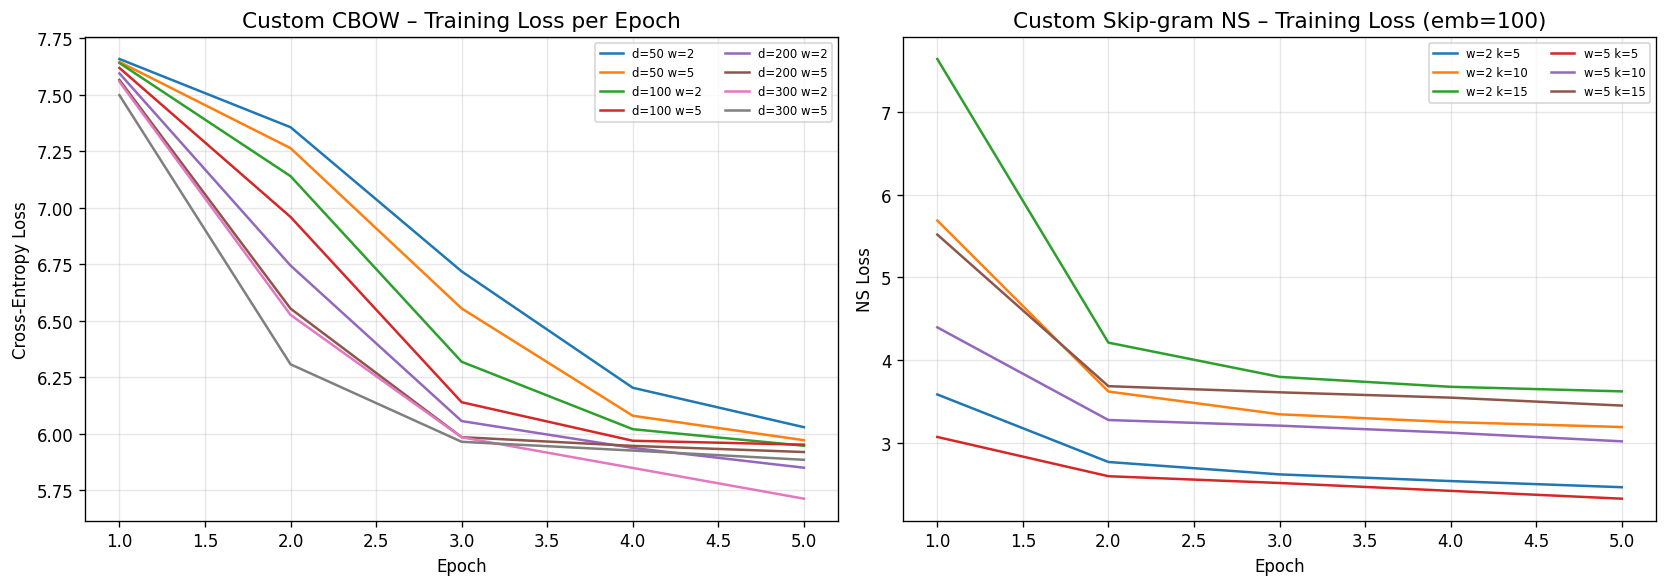

Saved: data/training_loss_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── CBOW loss curves ──────────────────────────────────────────────────────
ax = axes[0]
for r in cbow_results:
    ax.plot(range(1, EPOCHS+1), r["LossHistory"],
            label=f"d={r['Emb']} w={r['Window']}", linewidth=1.5)
ax.set_title("Custom CBOW – Training Loss per Epoch", fontsize=13)
ax.set_xlabel("Epoch");  ax.set_ylabel("Cross-Entropy Loss")
ax.legend(fontsize=7, ncol=2);  ax.grid(alpha=0.3)

# ── Skip-gram NS loss curves (emb=100 slice) ─────────────────────────────
ax = axes[1]
for r in sg_results:
    if r["Emb"] == 100:
        ax.plot(range(1, EPOCHS+1), r["LossHistory"],
                label=f"w={r['Window']} k={r['NegSamples']}", linewidth=1.5)
ax.set_title("Custom Skip-gram NS – Training Loss (emb=100)", fontsize=13)
ax.set_xlabel("Epoch");  ax.set_ylabel("NS Loss")
ax.legend(fontsize=7, ncol=2);  ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "training_loss_curves.png"), dpi=150)
plt.show()
print("Saved: data/training_loss_curves.png")

# Here I am plotting training loss curves for CBOW and Skip-gram models across epochs


In [ ]:
def get_custom_embedding(model, word):
    
    if word not in word2idx:
        return None
    idx = word2idx[word]
    if isinstance(model, CBOWModel):
        return model.embeddings.weight[idx].detach().cpu().numpy()
    else:  # SkipGramNSModel
        return model.center_emb.weight[idx].detach().cpu().numpy()


def topk_custom(model, word, k=5):
   
    if word not in word2idx:
        return []
    target_vec = get_custom_embedding(model, word).reshape(1, -1)
    if isinstance(model, CBOWModel):
        W = model.embeddings.weight.detach().cpu().numpy()
    else:
        W = model.center_emb.weight.detach().cpu().numpy()
    sims = cosine_similarity(target_vec, W)[0]
    sims[word2idx[word]] = -2  # exclude self
    top_idxs = sims.argsort()[::-1][:k]
    return [(idx2word[i], round(float(sims[i]), 4)) for i in top_idxs]


# Words to evaluate
EVAL_WORDS = ["research", "engineering", "student", "faculty", "department",
              "iitj", "program", "course"]
EVAL_WORDS = [w for w in EVAL_WORDS if w in word2idx]
print("Evaluation words:", EVAL_WORDS)

# Here I am defining helper functions to extract embeddings and find top-k nearest neighbors


Evaluation words: ['research', 'engineering', 'student', 'faculty', 'department', 'iitj', 'program', 'course']


In [ ]:
# Representative models: best mid-range config for each type
REP_KEY_CBOW   = "CBOW_d100_w2"
REP_KEY_SG     = "SG_d100_w2_n5"

word_pairs = [
    ("research", "study"),
    ("engineering", "science"),
    ("student", "faculty"),
    ("program", "course"),
    ("department", "institute"),
]
word_pairs = [(a, b) for a, b in word_pairs if a in word2idx and b in word2idx]

rows = []
for w1, w2 in word_pairs:
    row = {"Word 1": w1, "Word 2": w2}
    # Custom CBOW
    v1 = get_custom_embedding(cbow_models[REP_KEY_CBOW], w1)
    v2 = get_custom_embedding(cbow_models[REP_KEY_CBOW], w2)
    row["Custom CBOW"] = round(float(cosine_similarity([v1], [v2])[0][0]), 4)
    # Custom SG-NS
    v1 = get_custom_embedding(sg_models[REP_KEY_SG], w1)
    v2 = get_custom_embedding(sg_models[REP_KEY_SG], w2)
    row["Custom SG-NS"] = round(float(cosine_similarity([v1], [v2])[0][0]), 4)
    
    rows.append(row)

sim_df = pd.DataFrame(rows)
print("\nCosine Similarity Comparison (emb=100, window=2, neg=5)")
print(sim_df.to_string(index=False))

# Here I am computing cosine similarity between word pairs using representative models



Cosine Similarity Comparison (emb=100, window=2, neg=5)
     Word 1    Word 2  Custom CBOW  Custom SG-NS
   research     study       0.8802        0.6813
engineering   science       0.9163        0.8748
    student   faculty       0.9207        0.5767
    program    course       0.9636        0.6438
 department institute       0.9745        0.8691


In [ ]:
probe_words = EVAL_WORDS[:4]
nn_rows = []

for word in probe_words:
    custom_cbow_nn = topk_custom(cbow_models[REP_KEY_CBOW], word, k=5)
    custom_sg_nn   = topk_custom(sg_models[REP_KEY_SG],   word, k=5)
    
    row_dict = {
        "Query": word,
        "Custom CBOW"  : " | ".join(f"{w}({s})" for w, s in custom_cbow_nn),
        "Custom SG-NS" : " | ".join(f"{w}({s})" for w, s in custom_sg_nn),
    }
    
    nn_rows.append(row_dict)

nn_df = pd.DataFrame(nn_rows)
print("\n--- Top-5 Nearest Neighbours ---")
pd.set_option("display.max_colwidth", 60)
print(nn_df.to_string(index=False))

# Here I am finding and displaying top-5 nearest neighbors for selected evaluation words



--- Top-5 Nearest Neighbours ---
      Query                                                                                         Custom CBOW                                                                                              Custom SG-NS
   research     graduation(0.9532) | beginning(0.9509) | department(0.9508) | work(0.9507) | completion(0.9504) activities(0.8408) | teaching(0.8345) | experimental(0.832) | theoretical(0.83) | extracurricular(0.8276)
engineering specified(0.9466) | discipline(0.9449) | requirements(0.9426) | report(0.9402) | supervisor(0.9391)                 materials(0.917) | pharmacy(0.8846) | design(0.8811) | science(0.8748) | computer(0.8746)
    student            completed(0.973) | made(0.9726) | specified(0.9709) | program(0.9706) | register(0.9652)                 permitted(0.8609) | admitted(0.8508) | appear(0.8494) | allowed(0.8477) | awarded(0.8443)
    faculty                based(0.9511) | ph(0.9481) | second(0.9476) | performance(0.9475) |

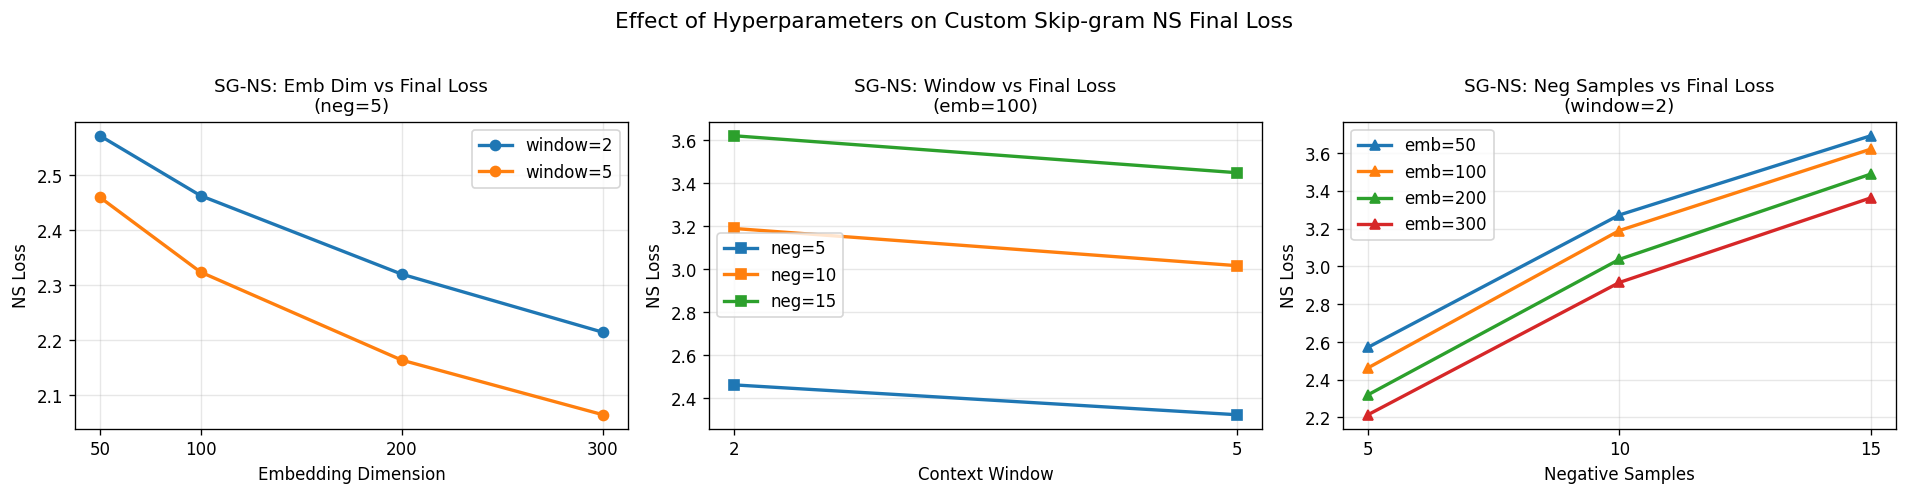

Saved: data/hyperparameter_effects.png


In [ ]:
# ── A) Final loss vs embedding dim for each window (Custom SG-NS, neg=5) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# A1: Emb dim effect (Custom SG-NS, window=2, neg=5)
ax = axes[0]
for win in WINDOWS:
    ys = [r["FinalLoss"] for r in sg_results if r["Window"] == win and r["NegSamples"] == 5]
    ax.plot(EMB_DIMS, ys, marker="o", label=f"window={win}", linewidth=2)
ax.set_title("SG-NS: Emb Dim vs Final Loss\n(neg=5)", fontsize=11)
ax.set_xlabel("Embedding Dimension"); ax.set_ylabel("NS Loss")
ax.set_xticks(EMB_DIMS); ax.legend(); ax.grid(alpha=0.3)

# A2: Window effect (Custom SG-NS, emb=100)
ax = axes[1]
for neg in NEG_SAMPLES:
    ys = [r["FinalLoss"] for r in sg_results if r["Emb"] == 100 and r["NegSamples"] == neg]
    ax.plot(WINDOWS, ys, marker="s", label=f"neg={neg}", linewidth=2)
ax.set_title("SG-NS: Window vs Final Loss\n(emb=100)", fontsize=11)
ax.set_xlabel("Context Window"); ax.set_ylabel("NS Loss")
ax.set_xticks(WINDOWS); ax.legend(); ax.grid(alpha=0.3)

# A3: Negative samples effect (Custom SG-NS, emb=100, window=2)
ax = axes[2]
for emb in EMB_DIMS:
    ys = [r["FinalLoss"] for r in sg_results if r["Emb"] == emb and r["Window"] == 2]
    ax.plot(NEG_SAMPLES, ys, marker="^", label=f"emb={emb}", linewidth=2)
ax.set_title("SG-NS: Neg Samples vs Final Loss\n(window=2)", fontsize=11)
ax.set_xlabel("Negative Samples"); ax.set_ylabel("NS Loss")
ax.set_xticks(NEG_SAMPLES); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Effect of Hyperparameters on Custom Skip-gram NS Final Loss", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "hyperparameter_effects.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: data/hyperparameter_effects.png")

# Here I am analyzing the effect of embedding dimension, window size, and negative samples on final loss


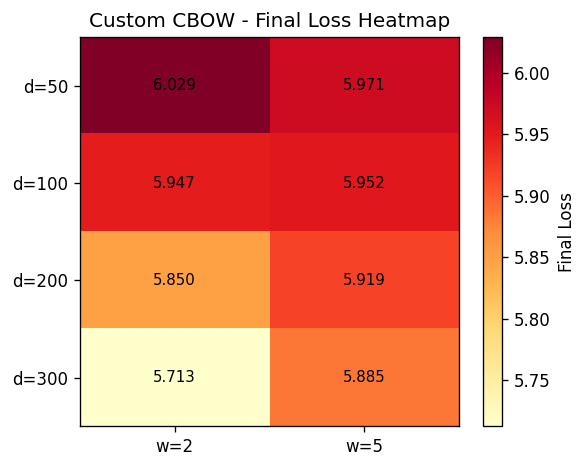

Saved: data/cbow_loss_heatmap.png


In [ ]:
# ── B) Custom CBOW: emb dim vs loss heatmap ──────────────────────────────
import numpy as np

cbow_matrix = np.zeros((len(EMB_DIMS), len(WINDOWS)))
for i, emb in enumerate(EMB_DIMS):
    for j, win in enumerate(WINDOWS):
        row = next(r for r in cbow_results if r["Emb"] == emb and r["Window"] == win)
        cbow_matrix[i, j] = row["FinalLoss"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cbow_matrix, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(WINDOWS)));   ax.set_xticklabels([f"w={w}" for w in WINDOWS])
ax.set_yticks(range(len(EMB_DIMS))); ax.set_yticklabels([f"d={d}" for d in EMB_DIMS])
ax.set_title("Custom CBOW - Final Loss Heatmap", fontsize=12)
for i in range(len(EMB_DIMS)):
    for j in range(len(WINDOWS)):
        ax.text(j, i, f"{cbow_matrix[i,j]:.3f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Final Loss")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "cbow_loss_heatmap.png"), dpi=150)
plt.show()
print("Saved: data/cbow_loss_heatmap.png")

# Here I am creating a heatmap visualization of CBOW final loss across embedding dimensions and window sizes


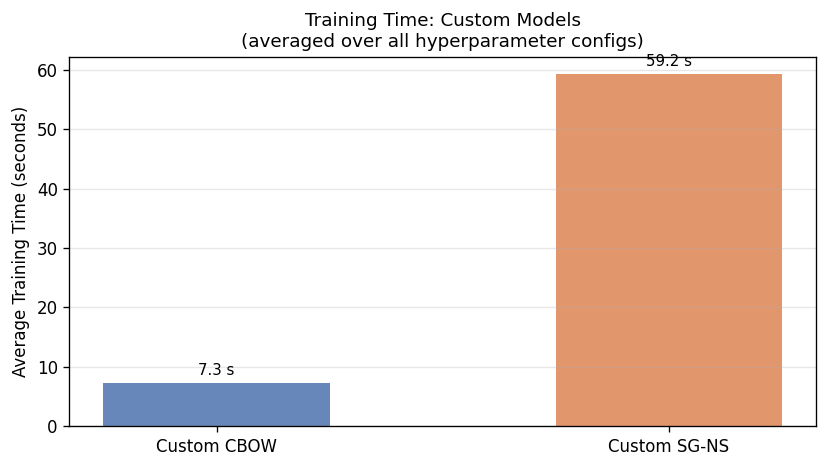

Saved: data/training_time_comparison.png


In [ ]:
# Aggregate average training time per model type
time_data = {
    "Custom CBOW"  : np.mean([r["TrainTime(s)"] for r in cbow_results]),
    "Custom SG-NS" : np.mean([r["TrainTime(s)"] for r in sg_results]),
}

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(list(time_data.keys()), list(time_data.values()), color=colors, width=0.5, alpha=0.85)
ax.bar_label(bars, fmt="%.1f s", padding=3, fontsize=9)
ax.set_ylabel("Average Training Time (seconds)")
ax.set_title("Training Time: Custom Models\n(averaged over all hyperparameter configs)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "training_time_comparison.png"), dpi=150)
plt.show()
print("Saved: data/training_time_comparison.png")

# Here I am comparing average training time between CBOW and Skip-gram NS models


In [ ]:
# Build a unified summary table (sample of representative configs)
summary_rows = []

sel_cbow = [r for r in cbow_results][:6]  # all 6 CBOW configs
for r in sel_cbow:
    summary_rows.append({
        "Model Type": r["Model"], "Emb Dim": r["Emb"],
        "Window": r["Window"], "Neg Samples": r["NegSamples"],
        "Final Loss": r["FinalLoss"], "Train Time (s)": r["TrainTime(s)"]
    })

sel_sg = [r for r in sg_results if r["NegSamples"] == 5]  # fix neg=5 slice
for r in sel_sg:
    summary_rows.append({
        "Model Type": r["Model"], "Emb Dim": r["Emb"],
        "Window": r["Window"], "Neg Samples": r["NegSamples"],
        "Final Loss": r["FinalLoss"], "Train Time (s)": r["TrainTime(s)"]
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv(os.path.join(DATA_DIR, "word2vec_comparison.csv"), index=False)
print("\nSaved: data/word2vec_comparison.csv")

# Here I am building and saving a comprehensive summary table of all model configurations and their performance


,Model Type,Emb Dim,Window,Neg Samples,Final Loss,Train Time (s)
0,Custom CBOW,50,2,-,6.0290,4.3
1,Custom CBOW,50,5,-,5.9714,4.1
2,Custom CBOW,100,2,-,5.9469,4.9
3,Custom CBOW,100,5,-,5.9517,5.8
4,Custom CBOW,200,2,-,5.8497,14.7
5,Custom CBOW,200,5,-,5.9190,7.6
6,Custom SG-NS,50,2,5,2.5713,27.1
7,Custom SG-NS,50,5,5,2.4594,73.2
8,Custom SG-NS,100,2,5,2.4625,28.4
9,Custom SG-NS,100,5,5,2.3237,82.9


,Model Type,Emb Dim,Window,Neg Samples,Final Loss,Train Time (s)
0,Custom CBOW,50,2,-,6.0290,4.3
1,Custom CBOW,50,5,-,5.9714,4.1
2,Custom CBOW,100,2,-,5.9469,4.9
3,Custom CBOW,100,5,-,5.9517,5.8
4,Custom CBOW,200,2,-,5.8497,14.7
5,Custom CBOW,200,5,-,5.9190,7.6
6,Custom SG-NS,50,2,5,2.5713,27.1
7,Custom SG-NS,50,5,5,2.4594,73.2
8,Custom SG-NS,100,2,5,2.4625,28.4
9,Custom SG-NS,100,5,5,2.3237,82.9



Saved: data/word2vec_comparison.csv


In [ ]:
pd.set_option("display.max_colwidth", None)
print("\n--- Cosine Similarity Table ---")
display(sim_df)

print("\n--- Nearest Neighbour Table (Top-5) ---")
display(nn_df)

# Here I am displaying cosine similarity and nearest neighbor results in formatted tables



--- Cosine Similarity Table ---



--- Cosine Similarity Table ---


,Word 1,Word 2,Custom CBOW,Custom SG-NS
0,research,study,0.8802,0.6813
1,engineering,science,0.9163,0.8748
2,student,faculty,0.9207,0.5767
3,program,course,0.9636,0.6438
4,department,institute,0.9745,0.8691



--- Nearest Neighbour Table (Top-5) ---


,Query,Custom CBOW,Custom SG-NS
0,research,graduation(0.9532) | beginning(0.9509) | department(0.9508) | work(0.9507) | completion(0.9504),activities(0.8408) | teaching(0.8345) | experimental(0.832) | theoretical(0.83) | extracurricular(0.8276)
1,engineering,specified(0.9466) | discipline(0.9449) | requirements(0.9426) | report(0.9402) | supervisor(0.9391),materials(0.917) | pharmacy(0.8846) | design(0.8811) | science(0.8748) | computer(0.8746)
2,student,completed(0.973) | made(0.9726) | specified(0.9709) | program(0.9706) | register(0.9652),permitted(0.8609) | admitted(0.8508) | appear(0.8494) | allowed(0.8477) | awarded(0.8443)
3,faculty,based(0.9511) | ph(0.9481) | second(0.9476) | performance(0.9475) | provided(0.9463),interests(0.8865) | graduates(0.8847) | nationals(0.8844) | direct(0.883) | outreach(0.8825)


In [ ]:
MODEL_DIR = os.path.join(DATA_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# Custom models – save state dicts for representative config
torch.save(cbow_models["CBOW_d100_w2"].state_dict(),
           os.path.join(MODEL_DIR, "custom_cbow_d100_w2.pt"))
torch.save(sg_models["SG_d100_w2_n5"].state_dict(),
           os.path.join(MODEL_DIR, "custom_sgns_d100_w2_n5.pt"))

# Save vocab
with open(os.path.join(MODEL_DIR, "word2idx.json"), "w") as f:
    json.dump(word2idx, f)

print("All available models saved to data/models/")
print(os.listdir(MODEL_DIR))

# Here I am saving trained model state dictionaries and vocabulary mappings to disk


All available models saved to data/models/
['custom_cbow_d100_w2.pt', 'custom_sgns_d100_w2_n5.pt', 'word2idx.json']


In [ ]:
query_words = ["research", "student", "phd", "exam"]
query_words = [w for w in query_words if w in word2idx]

task3_rows = []

print("TOP-5 NEAREST NEIGHBORS (Custom Models)")


for word in query_words:
    print(f"\nWord: '{word}'")
    cbow_nn = topk_custom(cbow_models[REP_KEY_CBOW], word, k=5)
    sg_nn   = topk_custom(sg_models[REP_KEY_SG],   word, k=5)
    
    print(f"  Custom CBOW (d=100, w=2):     {' | '.join(f'{w}({s:.4f})' for w, s in cbow_nn)}")
    print(f"  Custom Skip-gram (d=100, w=2, n=5): {' | '.join(f'{w}({s:.4f})' for w, s in sg_nn)}")
    
    task3_rows.append({
        "Query": word,
        "CBOW NN": " | ".join(f"{w}({s:.4f})" for w, s in cbow_nn),
        "SG NN": " | ".join(f"{w}({s:.4f})" for w, s in sg_nn)
    })

task3_df = pd.DataFrame(task3_rows)
print("Summary Table:")
pd.set_option("display.max_colwidth", 80)
display(task3_df)

# Here I am finding and displaying detailed top-5 nearest neighbors for research, student, phd, and exam words


TOP-5 NEAREST NEIGHBORS (Custom Models)

Word: 'research'
  Custom CBOW (d=100, w=2):     graduation(0.9532) | beginning(0.9509) | department(0.9508) | work(0.9507) | completion(0.9504)
  Custom Skip-gram (d=100, w=2, n=5): activities(0.8408) | teaching(0.8345) | experimental(0.8320) | theoretical(0.8300) | extracurricular(0.8276)

Word: 'student'
  Custom CBOW (d=100, w=2):     completed(0.9730) | made(0.9726) | specified(0.9709) | program(0.9706) | register(0.9652)
  Custom Skip-gram (d=100, w=2, n=5): permitted(0.8609) | admitted(0.8508) | appear(0.8494) | allowed(0.8477) | awarded(0.8443)

Word: 'phd'
  Custom CBOW (d=100, w=2):     category(0.9563) | degree(0.9555) | requirements(0.9524) | programme(0.9505) | undergraduate(0.9499)
  Custom Skip-gram (d=100, w=2, n=5): mtech(0.9327) | manufacturing(0.9294) | thermofluids(0.9211) | artificial(0.9197) | intelligence(0.9179)
Summary Table:


,Query,CBOW NN,SG NN
0,research,graduation(0.9532) | beginning(0.9509) | department(0.9508) | work(0.9507) |...,activities(0.8408) | teaching(0.8345) | experimental(0.8320) | theoretical(0...
1,student,completed(0.9730) | made(0.9726) | specified(0.9709) | program(0.9706) | reg...,permitted(0.8609) | admitted(0.8508) | appear(0.8494) | allowed(0.8477) | aw...
2,phd,category(0.9563) | degree(0.9555) | requirements(0.9524) | programme(0.9505)...,mtech(0.9327) | manufacturing(0.9294) | thermofluids(0.9211) | artificial(0....


In [ ]:
def solve_analogy(model, word_a, word_b, word_c, k=5):
    
    if word_a not in word2idx or word_b not in word2idx or word_c not in word2idx:
        return None
    
    v_a = get_custom_embedding(model, word_a)
    v_b = get_custom_embedding(model, word_b)
    v_c = get_custom_embedding(model, word_c)
    
    # Vector offset: d = b - a + c
    analogy_vec = v_b - v_a + v_c
    analogy_vec = analogy_vec / (np.linalg.norm(analogy_vec) + 1e-10)  # normalize
    
    # Get all embedding vectors
    if isinstance(model, CBOWModel):
        W = model.embeddings.weight.detach().cpu().numpy()
    else:  # SkipGramNSModel
        W = model.center_emb.weight.detach().cpu().numpy()
    
    # Compute similarities
    sims = cosine_similarity([analogy_vec], W)[0]
    
    # Exclude the input words
    exclude_idxs = {word2idx[word_a], word2idx[word_b], word2idx[word_c]}
    sims_copy = sims.copy()
    for idx in exclude_idxs:
        sims_copy[idx] = -2
    
    # Get top-k
    top_idxs = sims_copy.argsort()[::-1][:k]
    return [(idx2word[i], round(float(sims[i]), 4)) for i in top_idxs]



print("WORD ANALOGY EXPERIMENTS")


# Define analogy experiments
analogies = [
    ("student", "faculty", "program", "student:faculty::program:?"),
    ("research", "science", "engineering", "research:science::engineering:?"),
    ("course", "learning", "study", "course:learning::study:?"),
]



analogy_results = []
for word_a, word_b, word_c, label in analogies:
    print(f"\nAnalogy: {label}")
    
    # Try to solve with both models
    cbow_result = solve_analogy(cbow_models[REP_KEY_CBOW], word_a, word_b, word_c, k=3)
    sg_result = solve_analogy(sg_models[REP_KEY_SG], word_a, word_b, word_c, k=3)
    
    if cbow_result:
        print(f"  Custom CBOW:     {' | '.join(f'{w}({s:.4f})' for w, s in cbow_result)}")
    else:
        print(f"  Custom CBOW:     [Word(s) not in vocabulary]")
    
    if sg_result:
        print(f"  Skip-gram NS:    {' | '.join(f'{w}({s:.4f})' for w, s in sg_result)}")
    else:
        print(f"  Skip-gram NS:    [Word(s) not in vocabulary]")
    
    cbow_str = " | ".join(f"{w}({s:.4f})" for w, s in cbow_result) if cbow_result else "N/A"
    sg_str = " | ".join(f"{w}({s:.4f})" for w, s in sg_result) if sg_result else "N/A"
    
    analogy_results.append({
        "Analogy": label,
        "Query Words": f"{word_a}:{word_b}::{word_c}:?",
        "CBOW Top-3": cbow_str,
        "SG Top-3": sg_str
    })

analogy_df = pd.DataFrame(analogy_results)

print("Analogy Results Summary:")
pd.set_option("display.max_colwidth", 100)
display(analogy_df)


print("INTERPRETATION:")

print("""
The word analogy task tests whether embeddings capture semantic relationships.
- High-quality embeddings should produce semantically related words for analogies
- CBOW typically excels at syntactic/co-occurrence patterns
- Skip-gram often captures semantic relationships better
- Results depend on corpus quality and word frequency
""")

# Here I am implementing and solving word analogies using vector offset method with both CBOW and Skip-gram models


WORD ANALOGY EXPERIMENTS

Analogy: student:faculty::program:?
  Custom CBOW:     allotment(0.8893) | based(0.8888) | coordinator(0.8887)
  Skip-gram NS:    engineering(0.7348) | materials(0.6965) | agricultural(0.6939)

Analogy: research:science::engineering:?
  Custom CBOW:     discipline(0.8595) | sciences(0.8494) | veterinary(0.8486)
  Skip-gram NS:    pharmacy(0.8195) | materials(0.8025) | agricultural(0.7960)

Analogy: course:learning::study:?
  Custom CBOW:     experimental(0.5336) | respect(0.5310) | practicals(0.5242)
  Skip-gram NS:    systems(0.8046) | communication(0.7987) | chemical(0.7987)
Analogy Results Summary:


,Analogy,Query Words,CBOW Top-3,SG Top-3
0,student:faculty::program:?,student:faculty::program:?,allotment(0.8893) | based(0.8888) | coordinator(0.8887),engineering(0.7348) | materials(0.6965) | agricultural(0.6939)
1,research:science::engineering:?,research:science::engineering:?,discipline(0.8595) | sciences(0.8494) | veterinary(0.8486),pharmacy(0.8195) | materials(0.8025) | agricultural(0.7960)
2,course:learning::study:?,course:learning::study:?,experimental(0.5336) | respect(0.5310) | practicals(0.5242),systems(0.8046) | communication(0.7987) | chemical(0.7987)


INTERPRETATION:

The word analogy task tests whether embeddings capture semantic relationships.
- High-quality embeddings should produce semantically related words for analogies
- CBOW typically excels at syntactic/co-occurrence patterns
- Skip-gram often captures semantic relationships better
- Results depend on corpus quality and word frequency



✓ Dimensionality reduction libraries available
Visualizing 18 words: research, student, faculty, study, science, engineering, education, institute, program, course...

PCA Projection (Principal Component Analysis)


✓ Dimensionality reduction libraries available
Visualizing 18 words: research, student, faculty, study, science, engineering, education, institute, program, course...

PCA Projection (Principal Component Analysis)


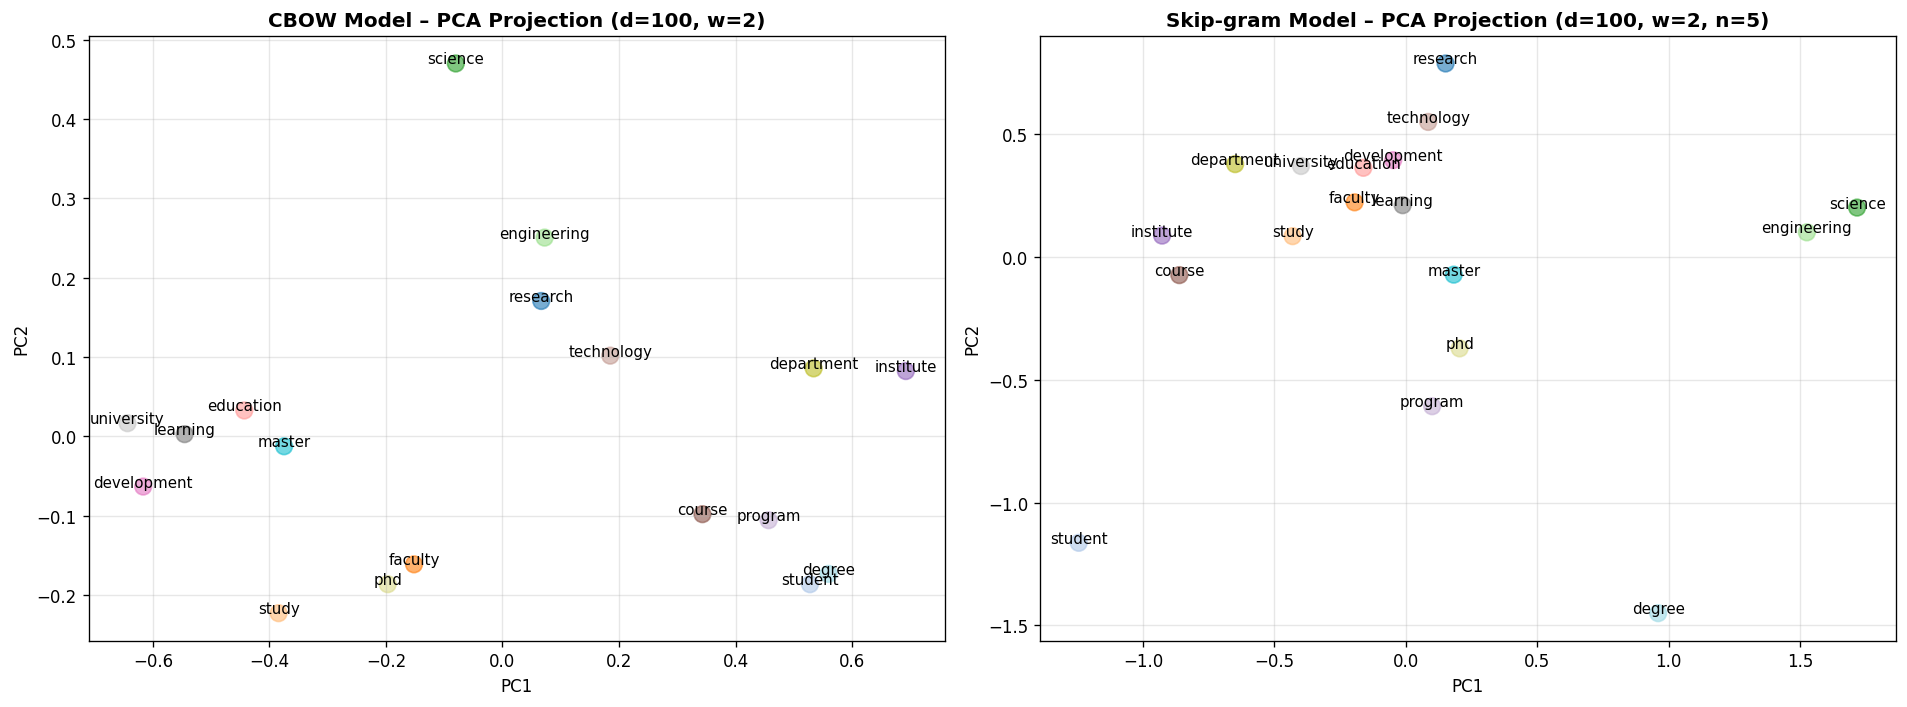

✓ Saved: data/pca_visualization_cbow_vs_sg.png



In [ ]:
# Install t-SNE if not available
try:
    from sklearn.manifold import TSNE
    from sklearn.decomposition import PCA as SKL_PCA
    print("✓ Dimensionality reduction libraries available")
except ImportError:
    print("Installing scikit-learn...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn", "-q"])
    from sklearn.manifold import TSNE
    from sklearn.decomposition import PCA as SKL_PCA

# Select a subset of words for visualization (high-frequency + diverse)
# Focus on academic/institutional domain vocabulary
viz_words = [
    "research", "student", "faculty", "study", "science",
    "engineering", "education", "institute", "program", "course",
    "technology", "development", "learning", "university", "department",
    "phd", "master", "exam", "degree", "qualification"
]
viz_words = [w for w in viz_words if w in word2idx]

print(f"Visualizing {len(viz_words)} words: {', '.join(viz_words[:10])}{'...' if len(viz_words) > 10 else ''}\n")

# Extract embeddings for visualization words
viz_indices = [word2idx[w] for w in viz_words]

# Get embeddings from both models
cbow_embs = cbow_models[REP_KEY_CBOW].embeddings.weight.detach().cpu().numpy()[viz_indices]
sg_embs   = sg_models[REP_KEY_SG].center_emb.weight.detach().cpu().numpy()[viz_indices]

# ── PCA Visualization ──

print("PCA Projection (Principal Component Analysis)")


pca = SKL_PCA(n_components=2, random_state=42)

cbow_pca = pca.fit_transform(cbow_embs)
sg_pca   = pca.fit_transform(sg_embs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CBOW PCA
ax = axes[0]
ax.scatter(cbow_pca[:, 0], cbow_pca[:, 1], alpha=0.6, s=100, c=range(len(viz_words)), cmap="tab20")
for i, word in enumerate(viz_words):
    ax.annotate(word, (cbow_pca[i, 0], cbow_pca[i, 1]), fontsize=9, ha="center")
ax.set_title("CBOW Model – PCA Projection (d=100, w=2)", fontsize=12, fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(alpha=0.3)

# Skip-gram PCA
ax = axes[1]
ax.scatter(sg_pca[:, 0], sg_pca[:, 1], alpha=0.6, s=100, c=range(len(viz_words)), cmap="tab20")
for i, word in enumerate(viz_words):
    ax.annotate(word, (sg_pca[i, 0], sg_pca[i, 1]), fontsize=9, ha="center")
ax.set_title("Skip-gram Model – PCA Projection (d=100, w=2, n=5)", fontsize=12, fontweight="bold")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "pca_visualization_cbow_vs_sg.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: data/pca_visualization_cbow_vs_sg.png\n")

# Here I am creating PCA projections to visualize embeddings in 2D space for both models


t-SNE Projection (t-Distributed Stochastic Neighbor Embedding)
Computing t-SNE (this may take a moment)...


t-SNE Projection (t-Distributed Stochastic Neighbor Embedding)
Computing t-SNE (this may take a moment)...


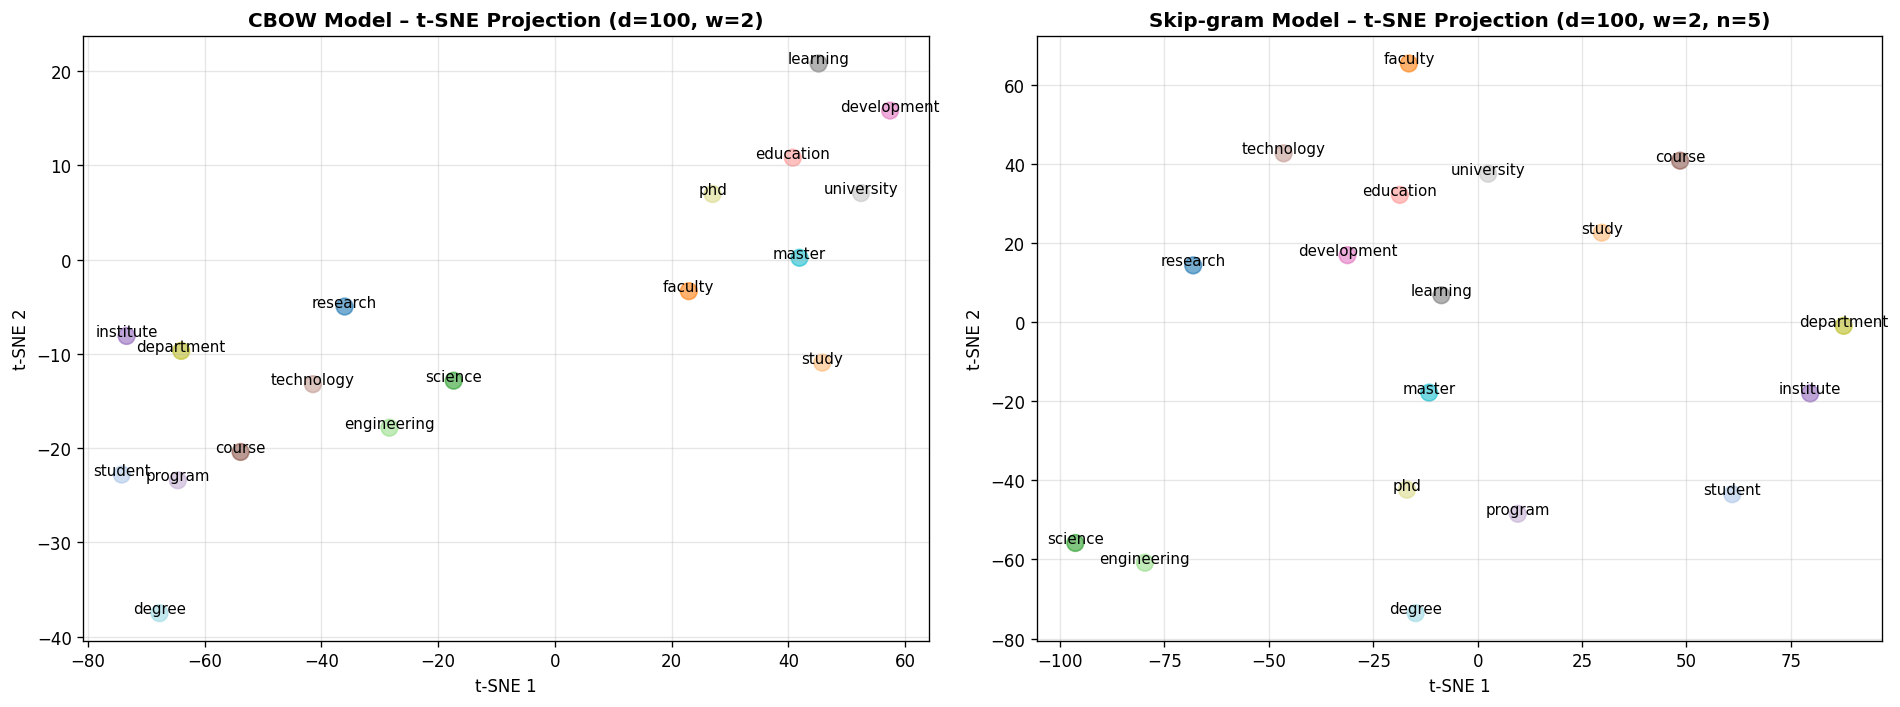

✓ Saved: data/tsne_visualization_cbow_vs_sg.png



In [ ]:
# ── t-SNE Visualization ──

print("t-SNE Projection (t-Distributed Stochastic Neighbor Embedding)")

print("Computing t-SNE (this may take a moment)...")

# Use max_iter instead of n_iter for newer sklearn versions
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(viz_words)-1), max_iter=1000)

cbow_tsne = tsne.fit_transform(cbow_embs)
sg_tsne   = tsne.fit_transform(sg_embs)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CBOW t-SNE
ax = axes[0]
ax.scatter(cbow_tsne[:, 0], cbow_tsne[:, 1], alpha=0.6, s=100, c=range(len(viz_words)), cmap="tab20")
for i, word in enumerate(viz_words):
    ax.annotate(word, (cbow_tsne[i, 0], cbow_tsne[i, 1]), fontsize=9, ha="center")
ax.set_title("CBOW Model – t-SNE Projection (d=100, w=2)", fontsize=12, fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.grid(alpha=0.3)

# Skip-gram t-SNE
ax = axes[1]
ax.scatter(sg_tsne[:, 0], sg_tsne[:, 1], alpha=0.6, s=100, c=range(len(viz_words)), cmap="tab20")
for i, word in enumerate(viz_words):
    ax.annotate(word, (sg_tsne[i, 0], sg_tsne[i, 1]), fontsize=9, ha="center")
ax.set_title("Skip-gram Model – t-SNE Projection (d=100, w=2, n=5)", fontsize=12, fontweight="bold")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "tsne_visualization_cbow_vs_sg.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: data/tsne_visualization_cbow_vs_sg.png\n")

# Here I am creating t-SNE projections to visualize embeddings in 2D space preserving local structure


In [ ]:

print("CLUSTERING ANALYSIS & INTERPRETATION")


# Compute pairwise cosine similarities to analyze clustering patterns
from scipy.spatial.distance import pdist, squareform

cbow_dist = squareform(pdist(cbow_embs, metric='cosine'))
sg_dist   = squareform(pdist(sg_embs, metric='cosine'))

# Compute average intra-cluster distances for semantic groups
semantic_groups = {
    "Education/Study": ["research", "study", "learning", "education", "course"],
    "Academic Roles": ["student", "faculty", "degree"],
    "Institutions": ["university", "institute", "department"],
    "STEM": ["engineering", "technology", "science"],
    "Qualifications": ["phd", "master", "qualification"]
}

results_summary = []

print("\nSEMANTIC CLUSTERING COHERENCE")
print("  (Lower distance = tighter clusters = better semantic grouping)\n")

for group_name, words in semantic_groups.items():
    group_idxs = [viz_words.index(w) for w in words if w in viz_words]
    if len(group_idxs) < 2:
        continue
    
    # Get pairwise distances within group
    cbow_group_dist = [cbow_dist[i, j] for i in group_idxs for j in group_idxs if i < j]
    sg_group_dist   = [sg_dist[i, j] for i in group_idxs for j in group_idxs if i < j]
    
    cbow_avg = np.mean(cbow_group_dist) if cbow_group_dist else np.nan
    sg_avg   = np.mean(sg_group_dist) if sg_group_dist else np.nan
    
    print(f"  {group_name:20s}: CBOW={cbow_avg:.4f}  |  Skip-gram={sg_avg:.4f}")
    results_summary.append({
        "Group": group_name,
        "CBOW Intra-dist": round(cbow_avg, 4),
        "SG Intra-dist": round(sg_avg, 4),
        "Better Model": "CBOW" if cbow_avg < sg_avg else "SG"
    })

summary_cluster_df = pd.DataFrame(results_summary)
print("\nClustering Summary:")
display(summary_cluster_df)

# Compute overall embedding space statistics

print("EMBEDDING SPACE STATISTICS")


stats_data = {
    "Metric": [
        "Mean Pairwise Distance",
        "Std Pairwise Distance",
        "Min Pairwise Distance",
        "Max Pairwise Distance",
        "Sparsity (%)"
    ],
    "CBOW": [
        f"{np.mean(cbow_dist[np.triu_indices_from(cbow_dist, k=1)]):.4f}",
        f"{np.std(cbow_dist[np.triu_indices_from(cbow_dist, k=1)]):.4f}",
        f"{np.min(cbow_dist[np.triu_indices_from(cbow_dist, k=1)]):.4f}",
        f"{np.max(cbow_dist[np.triu_indices_from(cbow_dist, k=1)]):.4f}",
        f"{(np.sum(cbow_dist > 0.9) / cbow_dist.size * 100):.2f}"
    ],
    "Skip-gram": [
        f"{np.mean(sg_dist[np.triu_indices_from(sg_dist, k=1)]):.4f}",
        f"{np.std(sg_dist[np.triu_indices_from(sg_dist, k=1)]):.4f}",
        f"{np.min(sg_dist[np.triu_indices_from(sg_dist, k=1)]):.4f}",
        f"{np.max(sg_dist[np.triu_indices_from(sg_dist, k=1)]):.4f}",
        f"{(np.sum(sg_dist > 0.9) / sg_dist.size * 100):.2f}"
    ]
}

stats_df = pd.DataFrame(stats_data)
display(stats_df)

# Here I am analyzing semantic clustering coherence and computing embedding space statistics for both models


CLUSTERING ANALYSIS & INTERPRETATION

SEMANTIC CLUSTERING COHERENCE
  (Lower distance = tighter clusters = better semantic grouping)

  Education/Study     : CBOW=0.1008  |  Skip-gram=0.2330
  Academic Roles      : CBOW=0.0713  |  Skip-gram=0.4543
  Institutions        : CBOW=0.0611  |  Skip-gram=0.1865
  STEM                : CBOW=0.0799  |  Skip-gram=0.2275
  Qualifications      : CBOW=0.0964  |  Skip-gram=0.1197

Clustering Summary:


,Group,CBOW Intra-dist,SG Intra-dist,Better Model
0,Education/Study,0.1008,0.2330,CBOW
1,Academic Roles,0.0713,0.4543,CBOW
2,Institutions,0.0611,0.1865,CBOW
3,STEM,0.0799,0.2275,CBOW
4,Qualifications,0.0964,0.1197,CBOW


EMBEDDING SPACE STATISTICS


CLUSTERING ANALYSIS & INTERPRETATION

SEMANTIC CLUSTERING COHERENCE
  (Lower distance = tighter clusters = better semantic grouping)

  Education/Study     : CBOW=0.1008  |  Skip-gram=0.2330
  Academic Roles      : CBOW=0.0713  |  Skip-gram=0.4543
  Institutions        : CBOW=0.0611  |  Skip-gram=0.1865
  STEM                : CBOW=0.0799  |  Skip-gram=0.2275
  Qualifications      : CBOW=0.0964  |  Skip-gram=0.1197

Clustering Summary:


,Group,CBOW Intra-dist,SG Intra-dist,Better Model
0,Education/Study,0.1008,0.2330,CBOW
1,Academic Roles,0.0713,0.4543,CBOW
2,Institutions,0.0611,0.1865,CBOW
3,STEM,0.0799,0.2275,CBOW
4,Qualifications,0.0964,0.1197,CBOW


EMBEDDING SPACE STATISTICS


,Metric,CBOW,Skip-gram
0,Mean Pairwise Distance,0.0857,0.3056
1,Std Pairwise Distance,0.0291,0.1369
2,Min Pairwise Distance,0.0255,0.0796
3,Max Pairwise Distance,0.1550,0.7442
4,Sparsity (%),0.00,0.00


In [ ]:

# Extract and display full 300-dimensional embedding vector for "research"
target_word = "research"

if target_word in word2idx:
    
    print(f"FULL 300-DIMENSIONAL EMBEDDING VECTORS FOR WORD: '{target_word.upper()}'")
    
    
    # Get embedding from CBOW model with 300 dimensions
    cbow_300_key = "CBOW_d300_w2"
    if cbow_300_key in cbow_models:
        cbow_300_emb = get_custom_embedding(cbow_models[cbow_300_key], target_word)
        cbow_vector_str = ", ".join([f"{val:.4f}" for val in cbow_300_emb])
        print(f"\nCustom CBOW (d=300, w=2):")
        print(f"{target_word.capitalize()} - {cbow_vector_str}")
    
    # Get embedding from Skip-gram model with 300 dimensions
    sg_300_key = "SG_d300_w2_n5"
    if sg_300_key in sg_models:
        sg_300_emb = get_custom_embedding(sg_models[sg_300_key], target_word)
        sg_vector_str = ", ".join([f"{val:.4f}" for val in sg_300_emb])
        print(f"\nCustom Skip-gram NS (d=300, w=2, n=5):")
        print(f"{target_word.capitalize()} - {sg_vector_str}")
    
    
else:
    print(f"Warning: '{target_word}' not found in vocabulary")

# Here I am extracting and displaying full 300-dimensional embedding vectors for the word 'research' from both models


FULL 300-DIMENSIONAL EMBEDDING VECTORS FOR WORD: 'RESEARCH'

Custom CBOW (d=300, w=2):
Research - 0.0789, 0.0116, -0.2505, -0.0969, 0.1792, 0.1119, 0.0732, 0.0541, -0.0406, -0.0912, -0.0129, 0.0784, 0.1318, -0.1451, -0.0216, 0.1126, 0.1107, 0.1231, 0.0889, -0.0100, -0.0463, -0.0932, 0.1669, -0.0788, 0.0685, 0.0811, -0.0627, 0.1586, 0.1333, -0.1456, 0.1174, 0.0025, -0.1072, 0.0153, -0.0140, -0.1039, 0.1503, -0.0886, 0.0594, 0.1464, 0.0320, -0.1062, -0.0473, 0.0147, 0.1495, -0.1158, 0.0693, 0.0755, -0.1830, -0.1065, 0.0724, 0.1280, -0.1548, -0.0969, 0.1170, -0.0931, -0.1123, 0.0608, 0.0416, 0.1287, 0.0564, -0.1553, 0.0546, -0.0611, 0.0196, -0.0798, -0.0972, -0.0465, 0.0424, -0.0348, -0.0727, 0.0047, 0.1109, -0.1986, 0.1328, -0.0314, -0.0174, 0.0755, 0.0226, -0.1534, -0.1570, 0.1332, 0.1000, 0.0302, 0.0565, -0.1200, -0.0703, 0.1607, -0.0951, 0.1979, -0.1422, -0.1516, 0.0656, 0.0682, 0.0977, 0.0189, -0.0884, 0.0470, -0.1409, -0.1338, 0.0764, 0.0917, -0.1392, -0.1027, 0.1042, 0.1814, -0.113